# Archive Note

Historical notebook preserved for provenance. Paths were updated to the current repo layout, but this notebook remains exploratory rather than part of the curated analysis flow.


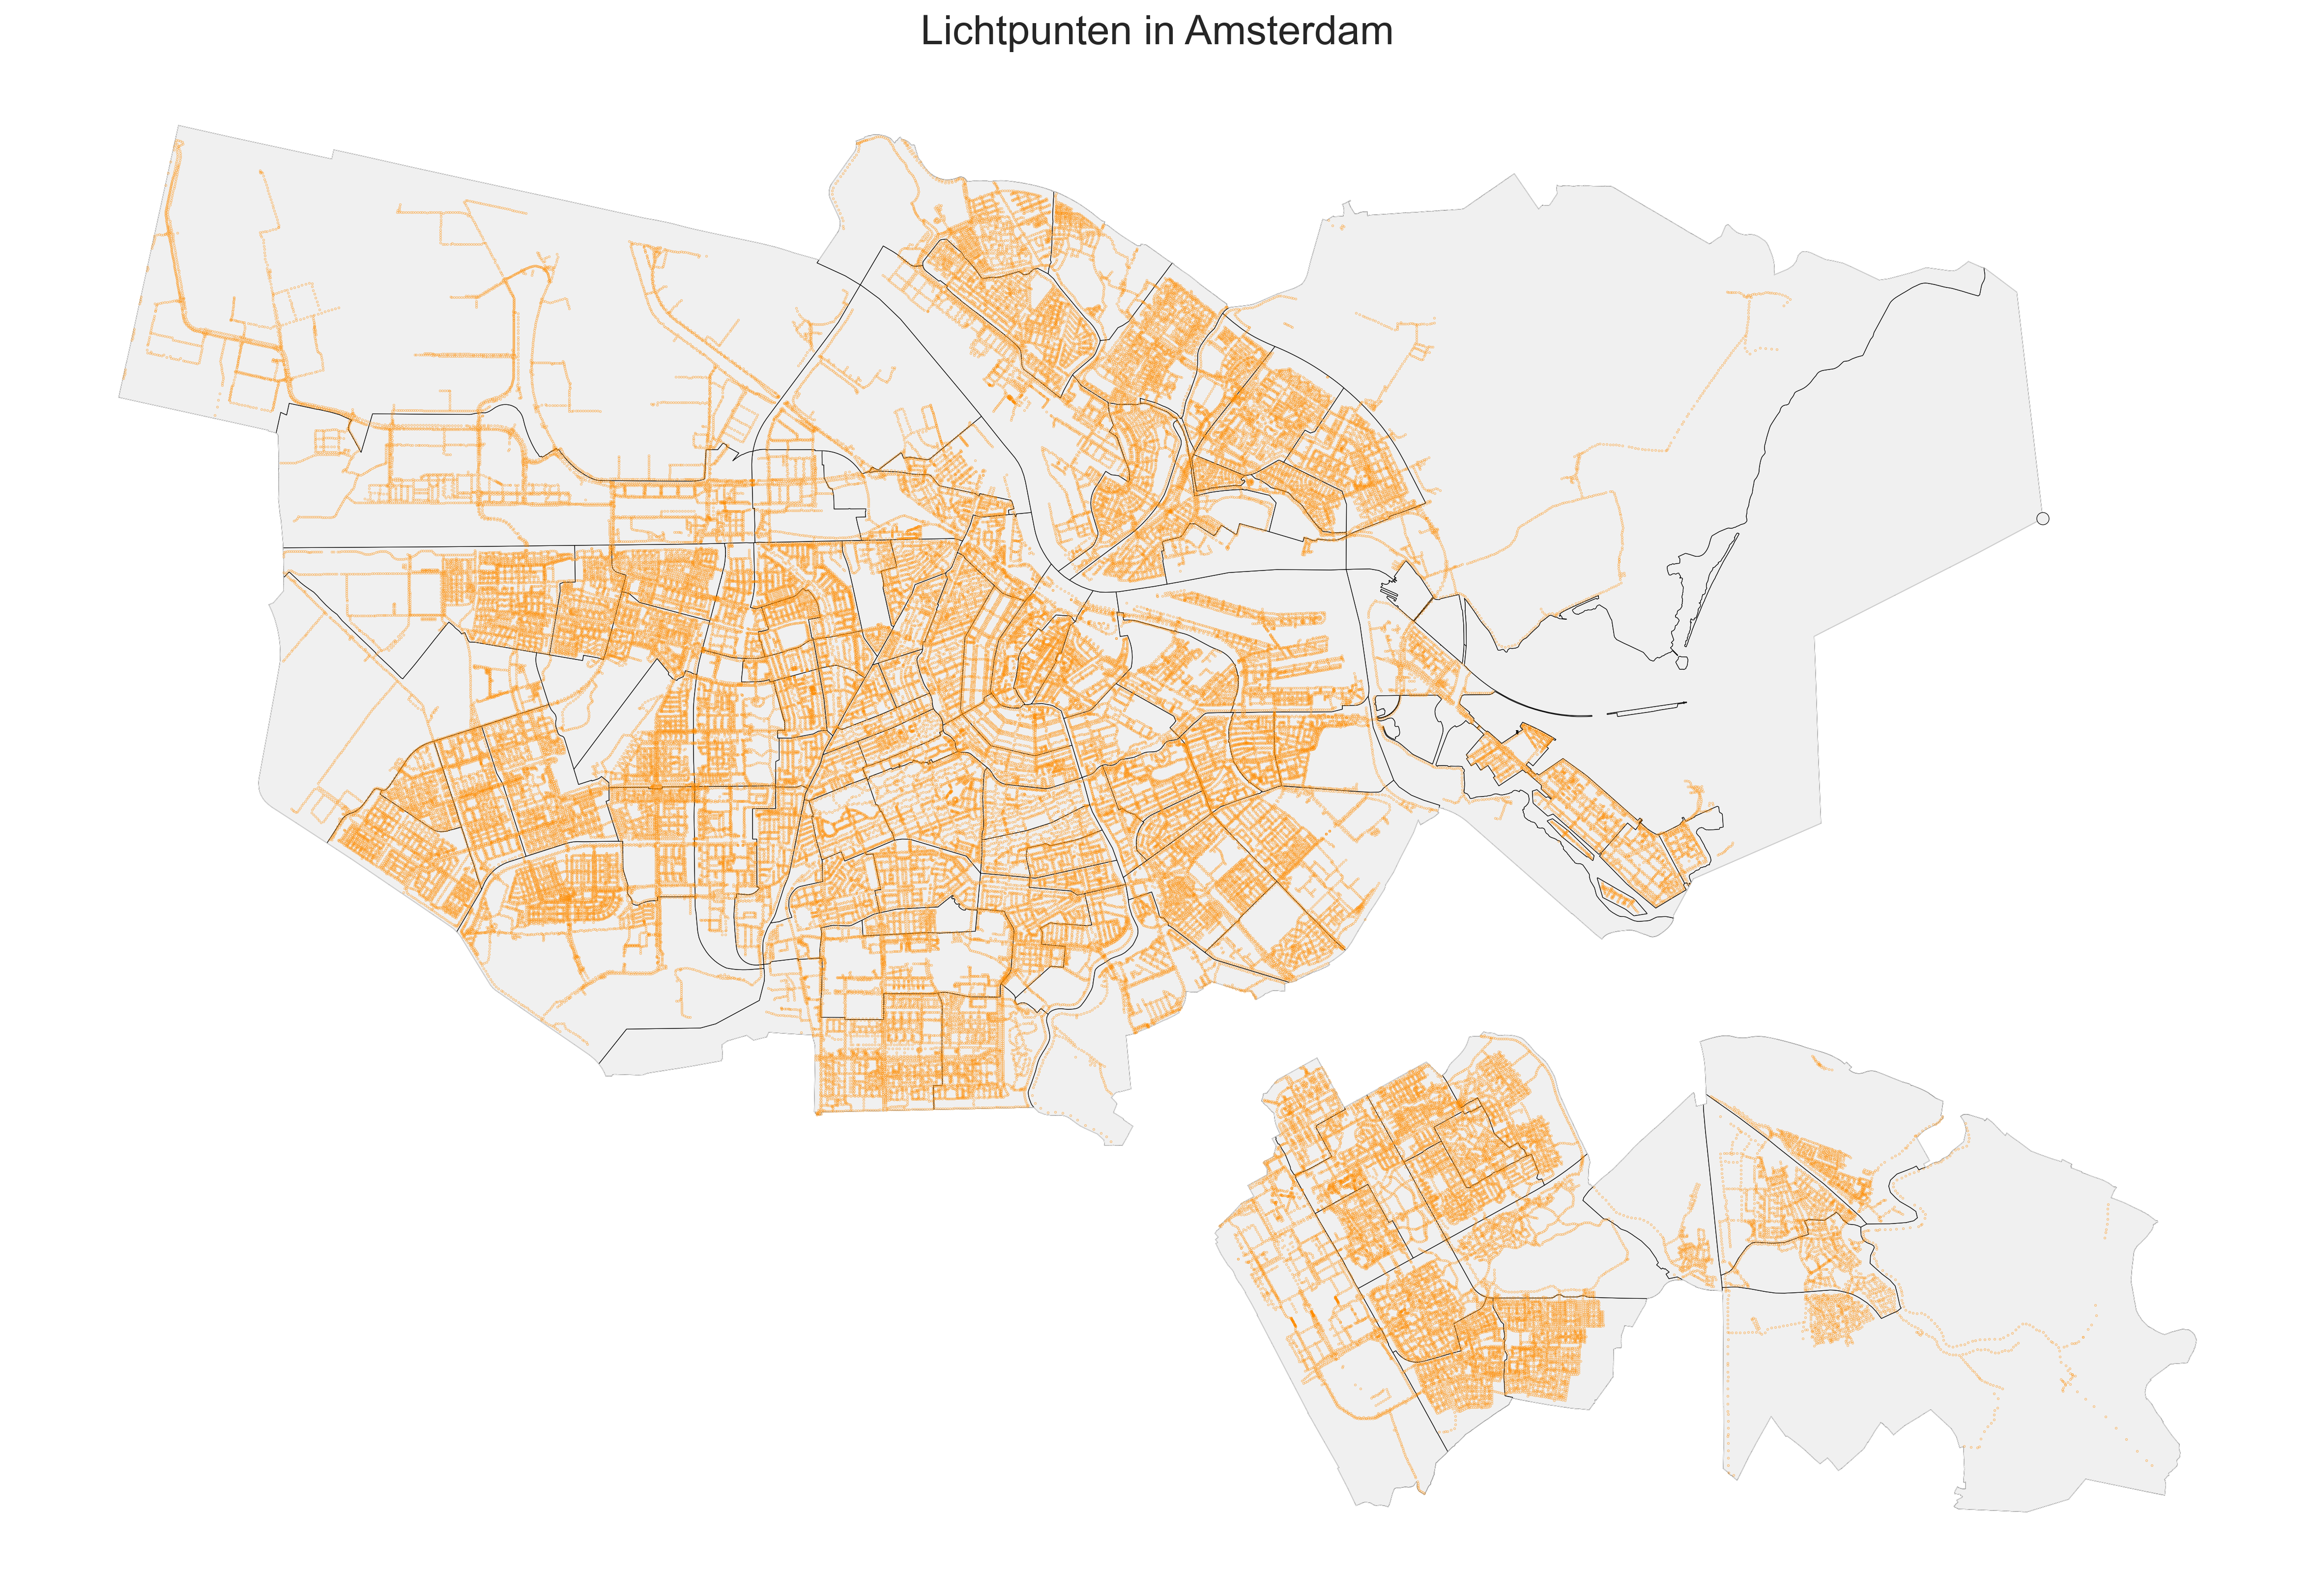

In [3]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt


"""

    Same as trees but with light

"""
gemeenten = gpd.read_file("../../data/raw/boundaries/wijken_en_gemeenten.gpkg", layer="gemeenten")
if gemeenten.crs is None:
    gemeenten = gemeenten.set_crs(epsg=28992)

amsterdam_grens = gemeenten[gemeenten['gemeentenaam'] == 'Amsterdam']


wijken = gpd.read_file("../../data/raw/boundaries/wijken_en_gemeenten.gpkg", layer="wijken")
if wijken.crs is None:
    wijken = wijken.set_crs(epsg=28992)


amsterdam_wijken = gpd.clip(wijken, amsterdam_grens)

df_licht = pd.read_csv("../../data/intermediate/LICHTPUNTEN_met_wijk.csv", sep=";")


df_licht_ams = df_licht[df_licht['gemeentenaam'] == 'Amsterdam'].copy()

lichtpunten = gpd.GeoDataFrame(
    df_licht_ams,
    geometry=gpd.points_from_xy(df_licht_ams.LNG, df_licht_ams.LAT),
    crs="EPSG:4326"
)

lichtpunten = lichtpunten.to_crs(epsg=28992)




fig, ax = plt.subplots(figsize=(20, 20), dpi=300)

amsterdam_wijken.plot(
    ax=ax,
    color='#f0f0f0',
    edgecolor='black',
    linewidth=0.3,
    zorder=1
)

lichtpunten.plot(
    ax=ax,
    color='darkorange',
    markersize=0.05,
    alpha=0.6,
    zorder=2
)

ax.set_title("Lichtpunten in Amsterdam", fontsize=20)
ax.set_axis_off()

plt.show()